# Analyse et modélisation des données de diagnostic

## Étape 1: Décompression du fichier et chargement des données

In [ ]:
# Importations nécessaires
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
# Décompresser le fichier ZIP
!unzip -o '/content/archive (2).zip' -d '/content/'

# Lister le contenu du dossier décompressé pour trouver le fichier CSV
print(os.listdir('/content/'))

# Assumons que le fichier CSV est nommé 'data.csv' ou similaire. Nous allons le charger.
# Si le nom du fichier est différent, veuillez modifier 'data.csv' ci-dessous.

try:
    df = pd.read_csv('/content/cancer_data.csv') # Common name after unzipping medical datasets
except FileNotFoundError:
    print("Le fichier 'cancer_data.csv' n'a pas été trouvé. Veuillez vérifier le nom du fichier.")
    # Tentative avec un autre nom courant si le premier échoue, ou demander à l'utilisateur
    try:
        df = pd.read_csv('/content/data.csv')
        print("Chargement de 'data.csv'.")
    except FileNotFoundError:
        print("Le fichier 'data.csv' n'a pas été trouvé non plus. Veuillez vérifier les fichiers décompressés.")
        df = None # Set df to None if neither file is found


if df is not None:
    print("Données chargées avec succès.")
    # Afficher les premières lignes
    display(df.head())

Archive:  /content/archive (2).zip
  inflating: /content/data.csv       
['.config', 'archive (2).zip', 'data.csv', 'sample_data']
Le fichier 'cancer_data.csv' n'a pas été trouvé. Veuillez vérifier le nom du fichier.
Chargement de 'data.csv'.
Données chargées avec succès.


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


## Étape 2: Analyse exploratoire des données (EDA)


Informations sur le DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64

/tmp/ipykernel_2571/3051769501.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='diagnosis', data=df, palette='magma')


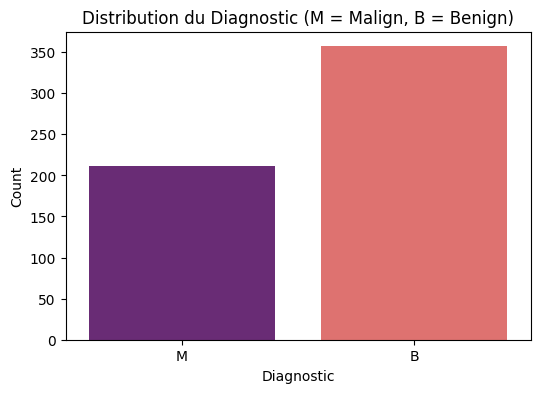

In [ ]:
# Vérifier les informations générales sur le DataFrame (types de données, valeurs non nulles)
print("\nInformations sur le DataFrame:")
df.info()

# Vérifier les valeurs manquantes
print("\nNombre de valeurs manquantes par colonne:")
print(df.isnull().sum())

# Si une colonne n'est pas utile (par exemple, 'Unnamed: 32' est souvent une colonne vide)
# Nous allons d'abord l'identifier à partir de df.info() ou df.head()
# Dans l'exemple typique de ce dataset, une colonne 'Unnamed: 32' est souvent présente et vide.
if 'Unnamed: 32' in df.columns:
    if df['Unnamed: 32'].isnull().all():
        print("\nSuppression de la colonne 'Unnamed: 32' car elle est vide.")
        df = df.drop(columns=['Unnamed: 32'])
    else:
        print("\nLa colonne 'Unnamed: 32' contient des valeurs et ne sera pas supprimée automatiquement.")

# Vérifier s'il y a d'autres colonnes avec une seule valeur unique (autre que l'ID) ou complètement vides qui pourraient être inutiles
for col in df.columns:
    if df[col].nunique() == 1 and col != 'id':
        print(f"\nSuppression de la colonne '{col}' car elle n'a qu'une seule valeur unique.")
        df = df.drop(columns=[col])

# Pour le diagnostic, nous devons vérifier les valeurs uniques
print("\nValeurs uniques dans la colonne 'diagnosis':")
print(df['diagnosis'].value_counts())

# Créer un graphique de comptage pour afficher le diagnostic
plt.figure(figsize=(6, 4))
sns.countplot(x='diagnosis', data=df, palette='magma')
plt.title('Distribution du Diagnostic (M = Malign, B = Benign)')
plt.xlabel('Diagnostic')
plt.ylabel('Count')
plt.show()

## Étape 3: Prétraitement des données

In [ ]:
# Convertir les valeurs catégorielles de 'diagnosis' en numériques
# 'M' (Malign) sera 1 et 'B' (Benign) sera 0
le = LabelEncoder()
df['diagnosis'] = le.fit_transform(df['diagnosis'])

print("Mapping des diagnostics :", list(le.classes_))
print("Premières lignes après encodage:")
display(df.head())

# Supprimer la colonne 'id' car elle n'est pas pertinente pour le modèle
df = df.drop(columns=['id'])

# Définir les caractéristiques (X) et la variable cible (y)
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

print("\nForme des caractéristiques (X):", X.shape)
print("Forme de la variable cible (y):", y.shape)

# Division des données en ensembles d'entraînement et d'essai
# 80% pour l'entraînement, 20% pour le test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("\nTaille de l'ensemble d'entraînement (X_train):", X_train.shape)
print("Taille de l'ensemble de test (X_test):", X_test.shape)
print("Taille de l'ensemble d'entraînement (y_train):", y_train.shape)
print("Taille de l'ensemble de test (y_test):", y_test.shape)

# Mise à l'échelle des caractéristiques numériques
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nCaractéristiques mises à l'échelle.")

Mapping des diagnostics : [np.int64(0), np.int64(1)]
Premières lignes après encodage:


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


KeyError: "['id'] not found in axis"

## Étape 4: Construction et évaluation des modèles de classification

In [ ]:
# Initialiser un dictionnaire pour stocker les précisions des modèles
model_accuracies = {}

# 1. Régression Logistique
print("\n--- Régression Logistique ---")
log_reg = LogisticRegression(random_state=42, solver='liblinear')
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)
accuracy_lr = accuracy_score(y_test, y_pred_lr)
model_accuracies['Logistic Regression'] = accuracy_lr
print(f"Précision: {accuracy_lr:.4f}")
print("Rapport de classification:")
print(classification_report(y_test, y_pred_lr))

# 2. K plus proches voisins (KNN)
print("\n--- K plus proches voisins (KNN) ---")
knn = KNeighborsClassifier(n_neighbors=5) # n_neighbors est un hyperparamètre à ajuster
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)
accuracy_knn = accuracy_score(y_test, y_pred_knn)
model_accuracies['K-Nearest Neighbors'] = accuracy_knn
print(f"Précision: {accuracy_knn:.4f}")
print("Rapport de classification:")
print(classification_report(y_test, y_pred_knn))

# 3. Forêts aléatoires
print("\n--- Forêts aléatoires ---")
random_forest = RandomForestClassifier(n_estimators=100, random_state=42) # n_estimators est un hyperparamètre
random_forest.fit(X_train_scaled, y_train)
y_pred_rf = random_forest.predict(X_test_scaled)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
model_accuracies['Random Forest'] = accuracy_rf
print(f"Précision: {accuracy_rf:.4f}")
print("Rapport de classification:")
print(classification_report(y_test, y_pred_rf))

# 4. Machines à vecteurs de support (SVM)
print("\n--- Machines à vecteurs de support (SVM) ---")
svm = SVC(random_state=42)
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)
accuracy_svm = accuracy_score(y_test, y_pred_svm)
model_accuracies['Support Vector Machine'] = accuracy_svm
print(f"Précision: {accuracy_svm:.4f}")
print("Rapport de classification:")
print(classification_report(y_test, y_pred_svm))


--- Régression Logistique ---
Précision: 0.9737
Rapport de classification:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98        72
           1       0.98      0.95      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114


--- K plus proches voisins (KNN) ---
Précision: 0.9561
Rapport de classification:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97        72
           1       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114


--- Forêts aléatoires ---
Précision: 0.9737
Rapport de classification:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
      

## Étape 5: Déterminer le meilleur modèle

In [ ]:
# Comparer les précisions des modèles et trouver le meilleur
best_model_name = max(model_accuracies, key=model_accuracies.get)
best_accuracy = model_accuracies[best_model_name]

print("\n--- Résumé des précisions des modèles ---")
for model, accuracy in model_accuracies.items():
    print(f"{model}: {accuracy:.4f}")

print(f"\nLe meilleur modèle est {best_model_name} avec une précision de {best_accuracy:.4f}.")


--- Résumé des précisions des modèles ---
Logistic Regression: 0.9737
K-Nearest Neighbors: 0.9561
Random Forest: 0.9737
Support Vector Machine: 0.9737

Le meilleur modèle est Logistic Regression avec une précision de 0.9737.


## Étape 3: Prétraitement des données

In [ ]:
# Convertir les valeurs catégorielles de 'diagnosis' en numériques
# 'M' (Malign) sera 1 et 'B' (Benign) sera 0
le = LabelEncoder()
df['diagnosis'] = le.fit_transform(df['diagnosis'])

print("Mapping des diagnostics :", list(le.classes_))
print("Premières lignes après encodage:")
display(df.head())

# Supprimer la colonne 'id' car elle n'est pas pertinente pour le modèle
df = df.drop(columns=['id'])

# Définir les caractéristiques (X) et la variable cible (y)
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

print("\nForme des caractéristiques (X):", X.shape)
print("Forme de la variable cible (y):", y.shape)

# Division des données en ensembles d'entraînement et d'essai
# 80% pour l'entraînement, 20% pour le test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("\nTaille de l'ensemble d'entraînement (X_train):", X_train.shape)
print("Taille de l'ensemble de test (X_test):", X_test.shape)
print("Taille de l'ensemble d'entraînement (y_train):", y_train.shape)
print("Taille de l'ensemble de test (y_test):", y_test.shape)

# Mise à l'échelle des caractéristiques numériques
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nCaractéristiques mises à l'échelle.")

Mapping des diagnostics : ['B', 'M']
Premières lignes après encodage:


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



Forme des caractéristiques (X): (569, 30)
Forme de la variable cible (y): (569,)

Taille de l'ensemble d'entraînement (X_train): (455, 30)
Taille de l'ensemble de test (X_test): (114, 30)
Taille de l'ensemble d'entraînement (y_train): (455,)
Taille de l'ensemble de test (y_test): (114,)

Caractéristiques mises à l'échelle.


## Étape 4: Construction et évaluation des modèles de classification

In [ ]:
# Initialiser un dictionnaire pour stocker les précisions des modèles
model_accuracies = {}

# 1. Régression Logistique
print("\n--- Régression Logistique ---")
log_reg = LogisticRegression(random_state=42, solver='liblinear')
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)
accuracy_lr = accuracy_score(y_test, y_pred_lr)
model_accuracies['Logistic Regression'] = accuracy_lr
print(f"Précision: {accuracy_lr:.4f}")
print("Rapport de classification:")
print(classification_report(y_test, y_pred_lr))

# 2. K plus proches voisins (KNN)
print("\n--- K plus proches voisins (KNN) ---")
knn = KNeighborsClassifier(n_neighbors=5) # n_neighbors est un hyperparamètre à ajuster
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)
accuracy_knn = accuracy_score(y_test, y_pred_knn)
model_accuracies['K-Nearest Neighbors'] = accuracy_knn
print(f"Précision: {accuracy_knn:.4f}")
print("Rapport de classification:")
print(classification_report(y_test, y_pred_knn))

# 3. Forêts aléatoires
print("\n--- Forêts aléatoires ---")
random_forest = RandomForestClassifier(n_estimators=100, random_state=42) # n_estimators est un hyperparamètre
random_forest.fit(X_train_scaled, y_train)
y_pred_rf = random_forest.predict(X_test_scaled)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
model_accuracies['Random Forest'] = accuracy_rf
print(f"Précision: {accuracy_rf:.4f}")
print("Rapport de classification:")
print(classification_report(y_test, y_pred_rf))

# 4. Machines à vecteurs de support (SVM)
print("\n--- Machines à vecteurs de support (SVM) ---")
svm = SVC(random_state=42)
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)
accuracy_svm = accuracy_score(y_test, y_pred_svm)
model_accuracies['Support Vector Machine'] = accuracy_svm
print(f"Précision: {accuracy_svm:.4f}")
print("Rapport de classification:")
print(classification_report(y_test, y_pred_svm))


--- Régression Logistique ---
Précision: 0.9737
Rapport de classification:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98        72
           1       0.98      0.95      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114


--- K plus proches voisins (KNN) ---
Précision: 0.9561
Rapport de classification:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97        72
           1       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114


--- Forêts aléatoires ---
Précision: 0.9737
Rapport de classification:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
      

## Étape 5: Déterminer le meilleur modèle

In [ ]:
# Comparer les précisions des modèles et trouver le meilleur
best_model_name = max(model_accuracies, key=model_accuracies.get)
best_accuracy = model_accuracies[best_model_name]

print("\n--- Résumé des précisions des modèles ---")
for model, accuracy in model_accuracies.items():
    print(f"{model}: {accuracy:.4f}")

print(f"\nLe meilleur modèle est {best_model_name} avec une précision de {best_accuracy:.4f}.")


--- Résumé des précisions des modèles ---
Logistic Regression: 0.9737
K-Nearest Neighbors: 0.9561
Random Forest: 0.9737
Support Vector Machine: 0.9737

Le meilleur modèle est Logistic Regression avec une précision de 0.9737.
